In [4]:
import os
import numpy as np               
import matplotlib.pyplot as plt  
from scattering import (a_of, simulate_angles, build_median_curve, estimate_Z,
                        B_MAX, E_ALPHA, Z_ALPHA, Z_GRID)
                        
os.chdir(r"C:/Users/Giannis/.vscode/01_monte_carlo_simulations")  # set working directory

In [5]:
# Physical setup shared by every cell below (lengths in femtometers, energies in MeV)

rng = np.random.default_rng(42)

E_alpha = 5.5                       # MeV, kinetic energy of the alpha particles
Z_alpha = 2                         # alpha particle charge number
b_max = B_MAX                       # fm, effective beam radius per nucleus - example

# Rutherford length a = [(0.5·k·e²)·Z_alpha·Z / E] in fm, using k·e² = 1.44 MeV·fm

# Is pure Coulomb (Rutherford) scattering a valid model for gold at this energy?

# fm, nuclear radius estimate: 1.2 · A^(1/3)

R_gold = 1.2 * 197 ** (1 / 3)        
print(f"Closest approach (head-on, gold): {2 * a_of(79):.1f} fm")
print(f"Gold nuclear radius:              {R_gold:.1f} fm")

# The alpha never reaches the nucleus, so pure Coulomb scattering is valid

Closest approach (head-on, gold): 45.5 fm
Gold nuclear radius:              7.0 fm


Particles simulated:                  10,000
Scattered particle angle < 30°:       9,787
Scattered particle angle 30°-90°:     195
Scattered particles angle > 90°:      18
Theoretical Scattered for > 90°:      16 ± 4
Difference:                           +15.4%, +2 particles difference
Deviation from theory:                +0.6 std


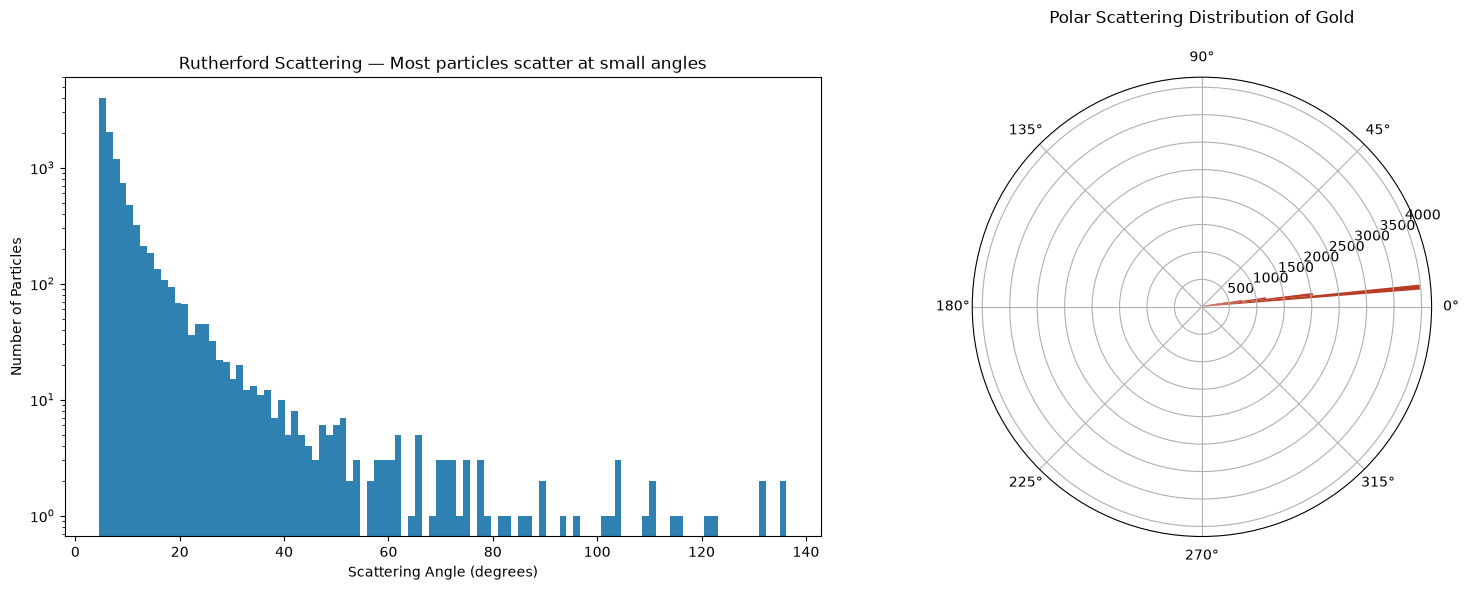

In [6]:
# Given known nucleus properties, predict scattering angle distribution

COLOR_1 = "#2E81B1"
COLOR_2 = "#B83B23"

n_particles = 10_000  
a = a_of(79)                 # Gold Nucleus              
b = b_max * np.sqrt(np.random.uniform(0, 1, n_particles))   # uniform over the beam's areatheta = 2 * np.arctan(a / b)
theta = 2 * np.arctan(a / b)

# Theory check: particles scattered beyond 90° are exactly those with b < a

p_90 = (a / b_max) ** 2                                # theoretical fraction beyond 90°
expected_90 = p_90 * n_particles
sigma_90 = np.sqrt(n_particles * p_90 * (1 - p_90))    # typical random fluctuation (1 standard deviation = std)
observed_90 = np.sum(theta > np.pi / 2)

print(f"Particles simulated:                  {n_particles:,}")
print(f"Scattered particle angle < 30°:       {np.sum(np.degrees(theta) < 30):,}")
print(f"Scattered particle angle 30°-90°:     {np.sum((np.degrees(theta) >= 30) & (theta <= np.pi/2)):,}")
print(f"Scattered particles angle > 90°:      {observed_90:,}")
print(f"Theoretical Scattered for > 90°:      {expected_90:,.0f} ± {sigma_90:,.0f}")
print(f"Difference:                           {(observed_90 - expected_90) / expected_90:+.1%}, "
      f"{observed_90 - expected_90:+,.0f} particles difference")
print(f"Deviation from theory:                {(observed_90 - expected_90) / sigma_90:+.1f} std")

fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(121)
ax1.hist(np.degrees(theta), bins=100, color=COLOR_1, edgecolor="none")
ax1.set_xlabel("Scattering Angle (degrees)")
ax1.set_ylabel("Number of Particles")
ax1.set_title("Rutherford Scattering — Most particles scatter at small angles")
ax1.set_yscale("log")

ax2 = fig.add_subplot(122, projection="polar")
ax2.hist(theta, bins=100, color=COLOR_2, edgecolor="none")
ax2.set_title("Polar Scattering Distribution of Gold", pad=20)

plt.tight_layout()
plt.savefig("results/02_particle_scattering.png", bbox_inches="tight")
plt.show()

True Z:      47 (Silver)
Estimated Z: 46
Error:       1 units


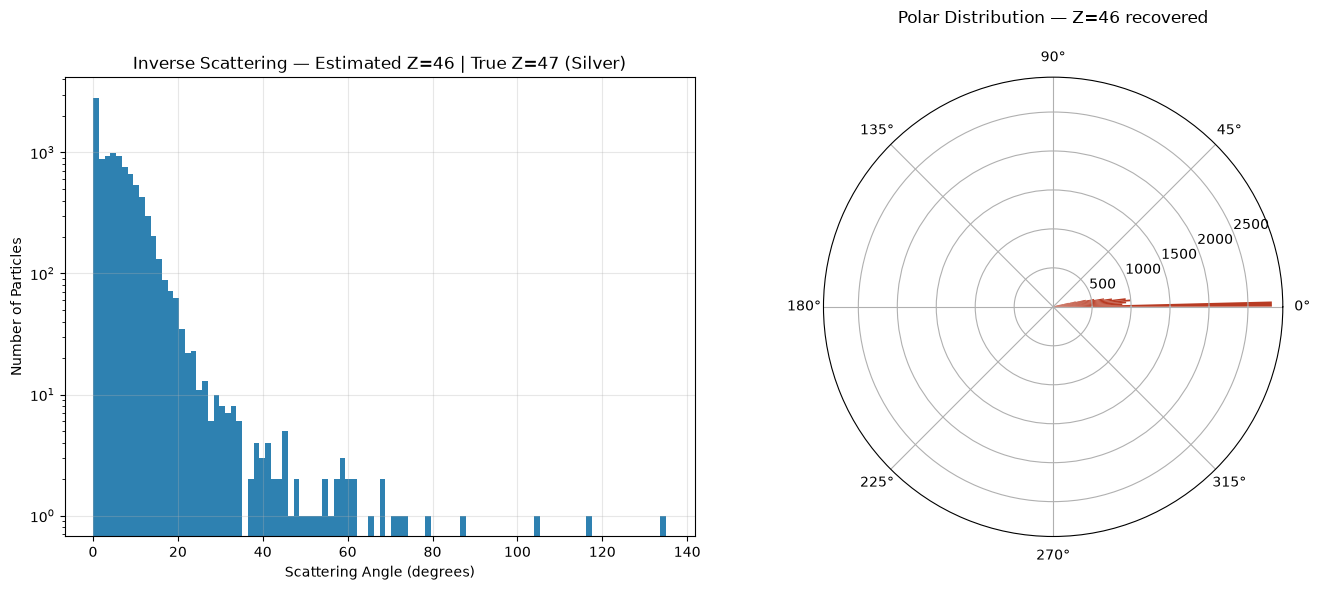

In [7]:
# Given only scattering angle distribution, determine unknown material's Z

Z_true = 47                         # Silver — hidden from the estimator
noise_level_degrees = 5.0           # detector angular noise (realistic: ~1, stress test: ~10)
n_particles = 10_000                # particles per experiment
Z_grid = np.arange(1, 119)          # every candidate atomic number

median_curve = build_median_curve(noise_level_degrees, rng=rng)

# The experiment: from here on the estimator only sees theta_mystery
theta_mystery = simulate_angles(Z_true, n_particles, noise_level_degrees, rng)
Z_estimated = estimate_Z(theta_mystery, median_curve)

print(f"True Z:      {Z_true} (Silver)")
print(f"Estimated Z: {Z_estimated}")
print(f"Error:       {abs(Z_true - Z_estimated)} units")

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121)
ax1.hist(np.degrees(theta_mystery), bins=100, color=COLOR_1, edgecolor="none")
ax1.set_xlabel("Scattering Angle (degrees)")
ax1.set_ylabel("Number of Particles")
ax1.set_title(f"Inverse Scattering — Estimated Z={Z_estimated} | True Z={Z_true} (Silver)")
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(122, projection="polar")
ax2.hist(theta_mystery, bins=100, color=COLOR_2, edgecolor="none")
ax2.set_title(f"Polar Distribution — Z={Z_estimated} recovered", pad=20)

plt.tight_layout()
plt.savefig("results/02_inverse_scattering.png", bbox_inches="tight")
plt.show()

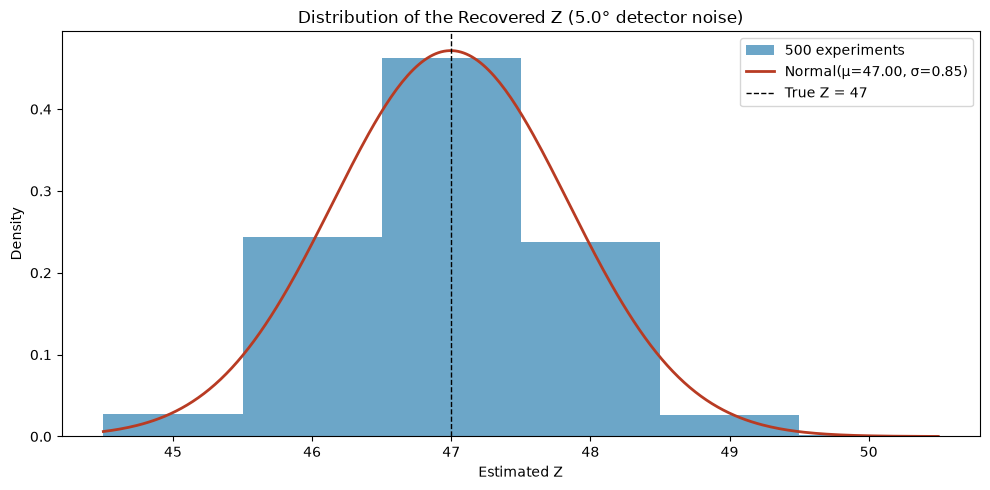

Mean estimate:      47.00
Std of estimate:    0.85
Exactly right:      46%
Within ±1 of truth: 94%


In [8]:
# Repeat the whole experiment many times: how spread out is the estimated Z?

n_experiments = 500
Z_estimates = np.array([
    estimate_Z(simulate_angles(Z_true, n_particles, noise_level_degrees, rng), median_curve)
    for _ in range(n_experiments)
])

mu, sigma = Z_estimates.mean(), Z_estimates.std()

bins = np.arange(Z_estimates.min() - 0.5, Z_estimates.max() + 1.5, 1)    # one bar per integer Z
grid = np.linspace(bins[0], bins[-1], 300)
normal_pdf = np.exp(-(grid - mu) ** 2 / (2 * sigma ** 2)) / (sigma * np.sqrt(2 * np.pi))

plt.figure(figsize=(10, 5))
plt.hist(Z_estimates, bins=bins, density=True, color=COLOR_1, alpha=0.7,
         label=f"{n_experiments} experiments")
plt.plot(grid, normal_pdf, color=COLOR_2, linewidth=2, label=f"Normal(μ={mu:.2f}, σ={sigma:.2f})")
plt.axvline(Z_true, color="k", linestyle="--", linewidth=1, label=f"True Z = {Z_true}")
plt.xlabel("Estimated Z")
plt.ylabel("Density")
plt.title(f"Distribution of the Recovered Z ({noise_level_degrees}° detector noise)")
plt.legend()
plt.tight_layout()
plt.savefig("results/02_inverse_distribution.png", bbox_inches="tight")
plt.show()

print(f"Mean estimate:      {mu:.2f}")
print(f"Std of estimate:    {sigma:.2f}")
print(f"Exactly right:      {np.mean(Z_estimates == Z_true):.0%}")
print(f"Within ±1 of truth: {np.mean(np.abs(Z_estimates - Z_true) <= 1):.0%}")

In [9]:
# How does detector noise limit the recovery of Z?

print(f"{'Noise':>7} | {'Mean Z':>7} | {'Std':>5} | {'Exactly right':>13} | {'Within ±1':>9}")
print("-" * 52)

for noise in [1.0, 5.0, 10.0]:
    curve = build_median_curve(noise, rng=rng)
    estimates = np.array([
        estimate_Z(simulate_angles(Z_true, n_particles, noise, rng), curve)
        for _ in range(n_experiments)
    ])
    print(f"{noise:>6.1f}° | {estimates.mean():>7.2f} | {estimates.std():>5.2f} | "
          f"{np.mean(estimates == Z_true):>13.0%} | {np.mean(np.abs(estimates - Z_true) <= 1):>9.0%}")

  Noise |  Mean Z |   Std | Exactly right | Within ±1
----------------------------------------------------
   1.0° |   47.03 |  0.27 |           93% |      100%
   5.0° |   46.95 |  0.81 |           52% |       94%
  10.0° |   46.99 |  1.41 |           25% |       71%
